In [ ]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
from reusable import *

### **Boundaries and setup**

In [ ]:
osm_path = r"sample_cities/copenhagen/Copenhagen.osm.pbf"
gtfs_path = r"sample_cities/copenhagen/GTFS_clean.zip"
pop_path = r"sample_cities/copenhagen/dnk_pd_2020_1km.tif"

osm = OSM(osm_path)
boundaries = osm.get_boundaries()

#correct_municipalities = [ 'Hvidovre Kommune', 'Dragør Kommune', 'Tårnby Kommune', 'Københavns Kommune']

In [4]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

In [5]:
city_boundary = boundaries[boundaries['admin_level'] == '7']
city_boundary = city_boundary[city_boundary['name'].str.endswith("Kommune")]

local_crs = city_boundary.estimate_utm_crs()
city_proj = city_boundary.to_crs(local_crs)

<Axes: >

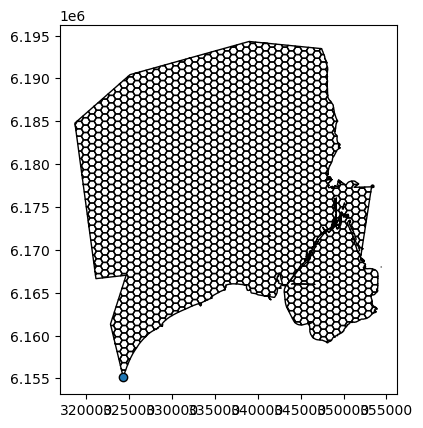

In [6]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  3,278,435
Hex grid total population: 3,250,702
Coverage: 99.2%


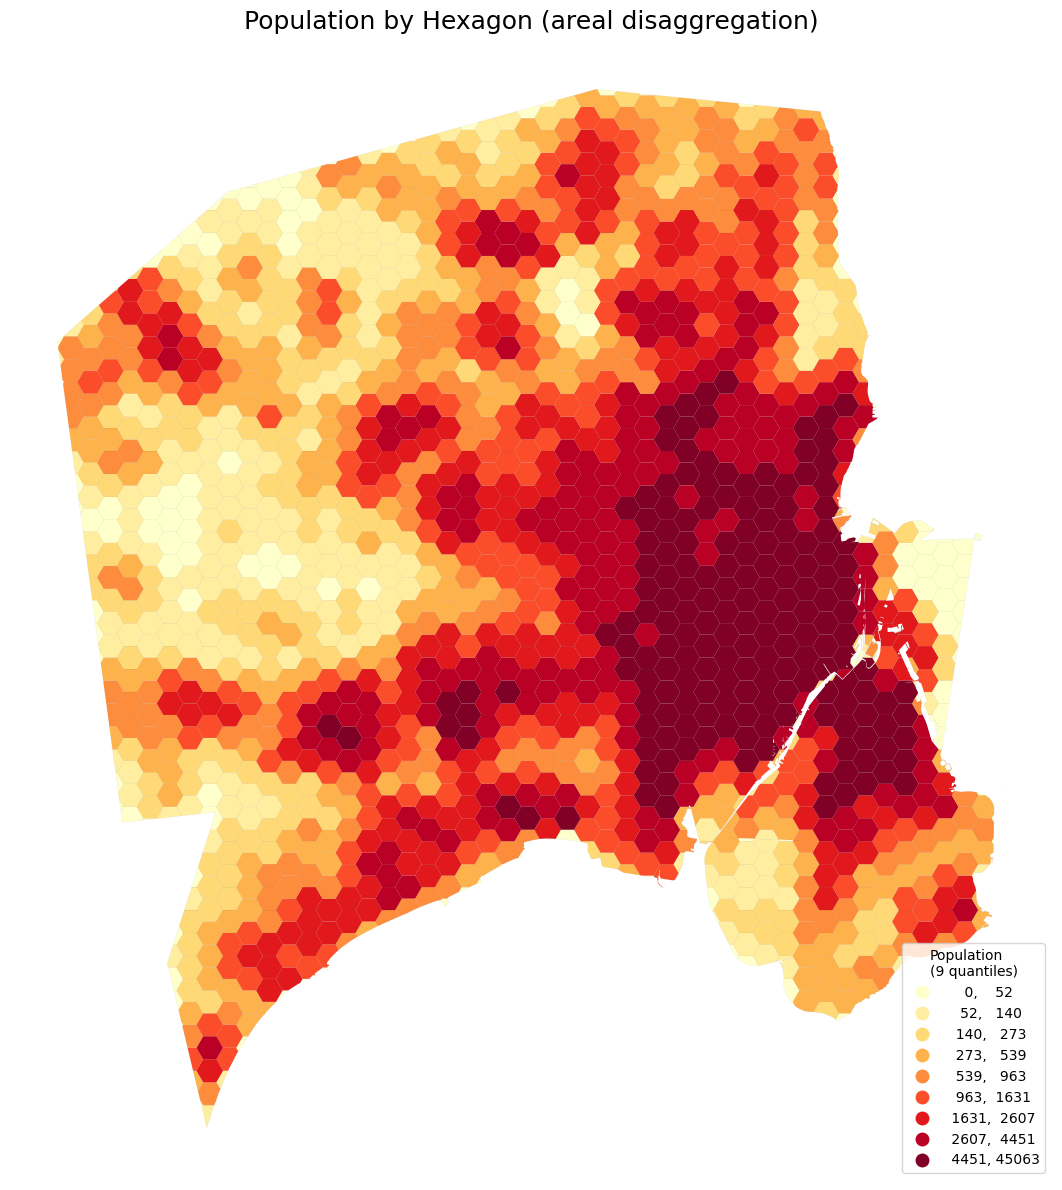

In [8]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

### OSM data exploration

In [ ]:
landuse = osm.get_landuse()
buildings = osm.get_buildings()
drive_net = osm.get_network(network_type="driving")

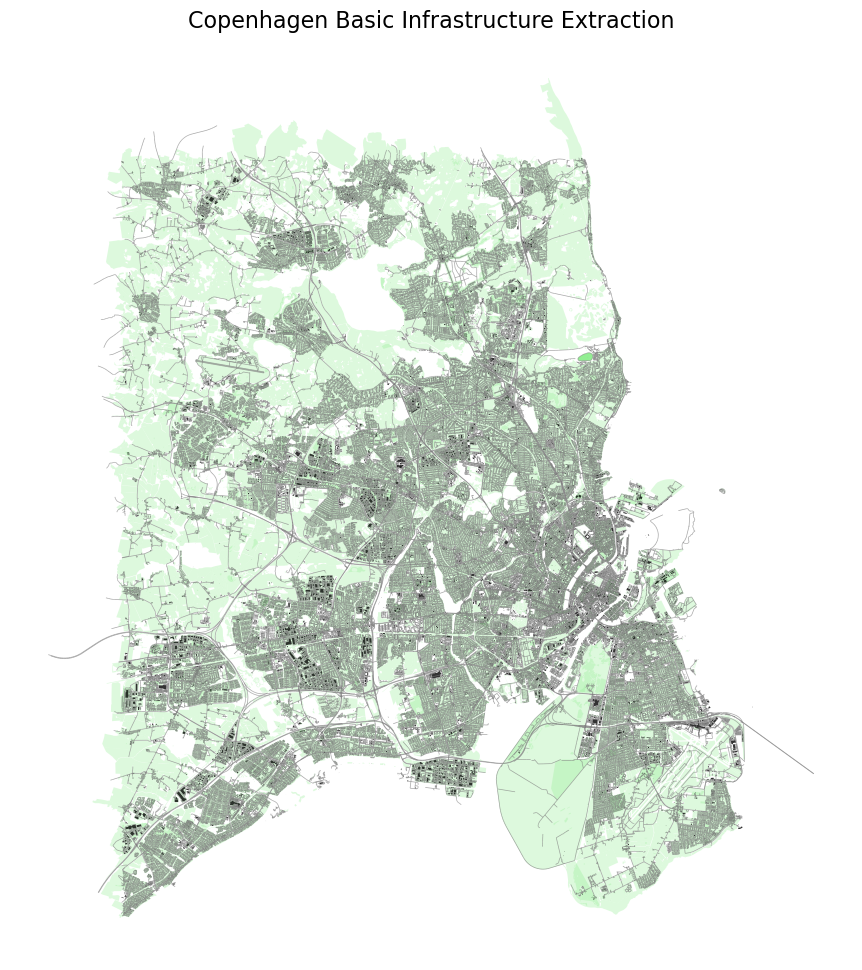

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

if landuse is not None and not landuse.empty:
    landuse.plot(ax=ax, color='lightgreen', alpha=0.3, edgecolor='none')

if drive_net is not None and not drive_net.empty:
    drive_net.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7)

if buildings is not None and not buildings.empty:
    buildings.plot(ax=ax, color='black', alpha=0.8)

ax.set_title("Copenhagen Basic Infrastructure Extraction", fontsize=16)
ax.set_axis_off()
plt.show()

In [9]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/copenhagen_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

City-wide baseline distribution:
  count_community: 0.055
  count_education: 0.085
  count_essential_services: 0.045
  count_food_and_drink: 0.710
  count_healthcare: 0.079
  count_shelter: 0.026


#### **Origins**

In [10]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (12.21748 55.5105),0,127.961563
1,POINT (12.21747 55.51568),1,0.000000
2,POINT (12.21382 55.51854),2,952.028181
3,POINT (12.21785 55.52234),3,402.612659
4,POINT (12.211 55.52669),4,83.476405


#### **Destinations (POIs)**

In [11]:
destinations = create_POIs(osm, summary=True)

Total amenities: 11550

By type:
amenity class
food_and_drink        5127
education             1062
healthcare             864
charging_station       832
community              545
toilets                471
shelter                349
essential_services     314
fuel                   236
fountain               177


#### **Min. dist. +  gravity weighed accessibility**

In [12]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']
essentials = destinations[destinations['amenity class'].isin(categories)]

In [13]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=20) #CUTOFF
)

In [14]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)
min_tt_wide.head(10)

,from_id,min_tt_community,min_tt_education,min_tt_essential_services,min_tt_food_and_drink,min_tt_healthcare,min_tt_shelter,avg_tt,n_unreachable_categories
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
4,1000,NaN,NaN,NaN,NaN,NaN,16.0,16.00,5
5,1001,9.0,10.0,NaN,10.0,20.0,NaN,12.25,2
6,1002,15.0,11.0,NaN,8.0,8.0,NaN,10.50,2
7,1003,18.0,12.0,NaN,4.0,4.0,NaN,9.50,2
8,1004,9.0,7.0,NaN,14.0,NaN,NaN,10.00,3
9,1005,NaN,13.0,NaN,2.0,13.0,14.0,10.50,2


In [15]:
res = merge_geometry(min_tt_wide, grid)

In [16]:
no_grav_beta = suggested_beta(23, target_weight=1)
no_grav_beta

-0.0

In [17]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)
no_gravity.head(5)

,from_id,gravity_community,gravity_education,gravity_essential_services,gravity_food_and_drink,gravity_healthcare,gravity_shelter,avg_gravity
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,10,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,100,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,1000,0.0,0.0,0.0,0.0,0.0,1.0,0.166667


In [18]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)
gravity.head(5)

,from_id,gravity_community,gravity_education,gravity_essential_services,gravity_food_and_drink,gravity_healthcare,gravity_shelter,avg_gravity
0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,10,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,100,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,1000,0.0,0.0,0.0,0.0,0.0,0.356864,0.059477


In [19]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

In [20]:
pop_weighed = merge_geometry(pop_weighed, grid)

#### **Diverisity of accessibility**

In [21]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)
diversity.head(10)

City-wide baseline distribution:
  gravity_community: 0.060
  gravity_education: 0.110
  gravity_essential_services: 0.042
  gravity_food_and_drink: 0.662
  gravity_healthcare: 0.092
  gravity_shelter: 0.034


,from_id,shannon,kl_divergence,jsd,city_similarity
0,0,1.381551e-08,0.602817,0.379968,0.620032
1,1,1.381551e-08,0.602817,0.379968,0.620032
2,10,1.381551e-08,0.602817,0.379968,0.620032
3,100,1.381551e-08,0.602817,0.379968,0.620032
4,1000,1.141293e-08,3.377780,0.786236,0.213764
5,1001,1.168282e+00,0.219598,0.239647,0.760353
6,1002,1.118969e+00,0.319371,0.276456,0.723544
7,1003,9.057885e-01,0.855421,0.417428,0.582572
8,1004,9.502705e-01,0.301610,0.292461,0.707539
9,1005,1.019453e+00,0.852460,0.424745,0.575255


In [22]:
diversity = merge_geometry(diversity, grid)

In [23]:
no_gravity = merge_geometry(no_gravity, grid)
gravity = merge_geometry(gravity,grid)

In [24]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 11.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 12.
  self.bins = quantile(y, k=k)


Note: 721 hexes have NaN for 'min_tt_food_and_drink' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 18.
  self.bins = quantile(y, k=k)


Note: 539 hexes have NaN for 'avg_tt' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting

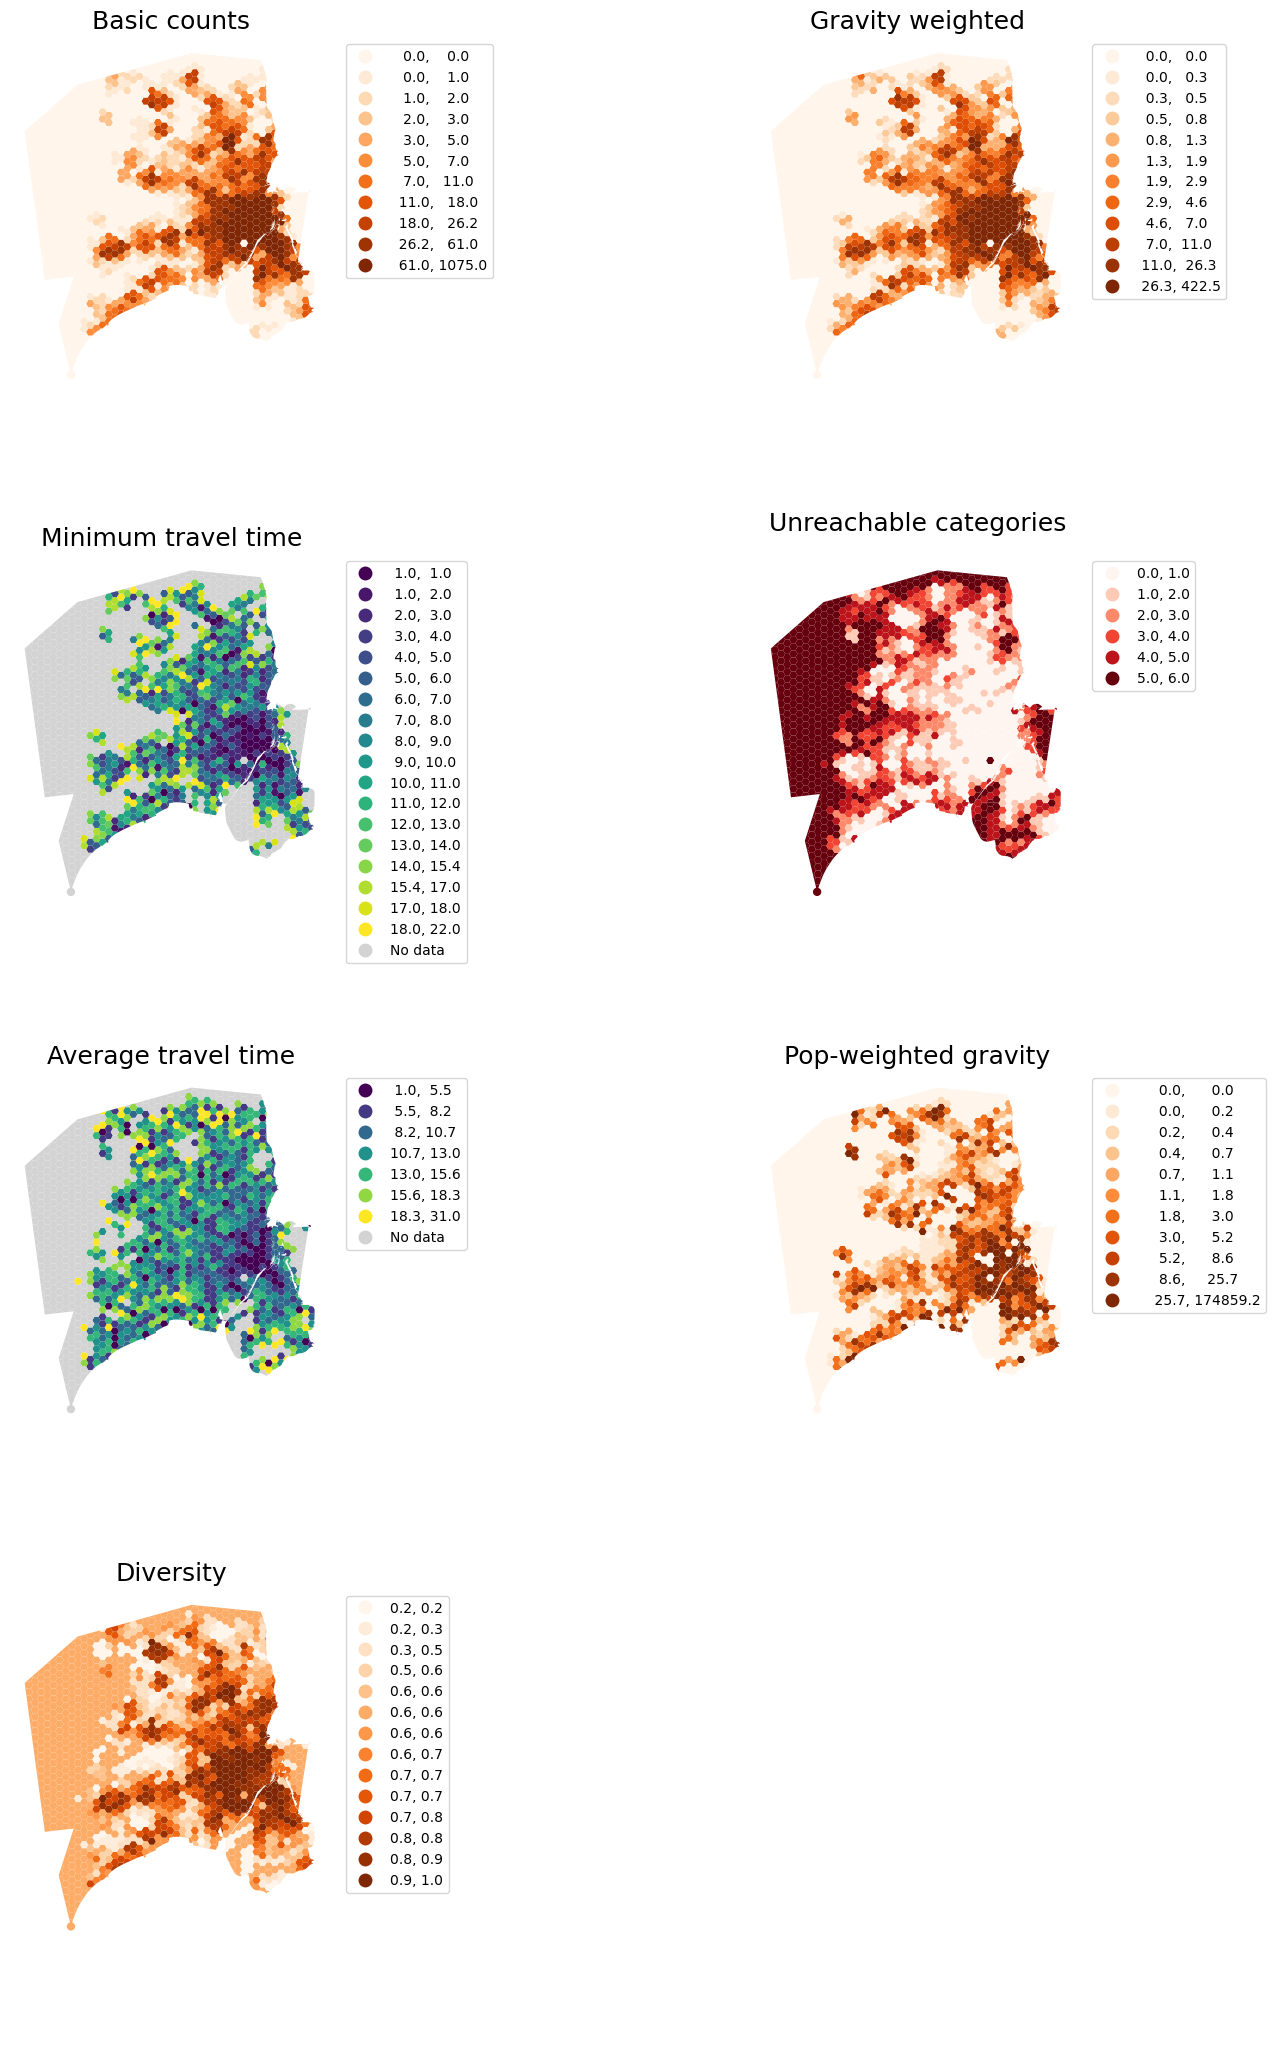

In [25]:
fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("copenhagen_results.png", dpi=300, bbox_inches="tight")